## <span style= "color : #696fc7">目標 : 計算各公司年報中 "經濟不確定性" 出現次數 </span>
## <span style= "color : #696fc7">檔案參考 : test_TSMC_2024.ipynb </span>

### 年報中"經濟不確定性" 出現次數範例 : 以 2330台積電 為例 <span style= "color : #d11c1c">(萃取文字)</span>
<a href="https://ppt.cc/fTpxVx"><img src="https://ppt.cc/fTpxVx@.png" border="0" alt="PPT.cc縮圖服務" title="PPT.cc縮圖服務"></a>

### 年報中"經濟不確定性" 出現次數範例 : 以 2330台積電 為例 <span style= "color : #d11c1c">(計算關鍵字次數)</span>
<a href="https://ppt.cc/fxAWHx"><img src="https://ppt.cc/fxAWHx@.png" border="0" alt="PPT.cc縮圖服務" title="PPT.cc縮圖服務"></a>

In [5]:
import pandas as pd
import numpy as np 
import pdfplumber
df_fs=pd.read_csv(r"C:\Users\user\Documents\實證研究\python_ds\實證模型.csv",encoding="cp950")
df_fs_code=df_fs["代號"]
print(df_fs_code.head())

0    1101
1    1102
2    1103
3    1104
4    1108
Name: 代號, dtype: int64


#### 可用format格式 + df_fs_code資料取得各公司年份檔案路徑

In [ ]:
print(r"C:\Users\user\Documents\實證研究\pdf_crawling\年報\2024_1101.pdf")
print(fr"C:\Users\user\Documents\實證研究\pdf_crawling\年報\2024_{df_fs_code[0]}.pdf")
num=0
### 用迴圈測試檔案路徑是否符合格式
for i in range(len(df_fs_code)):
    num+=1
    print(fr"C:\Users\user\Documents\實證研究\pdf_crawling\年報\2024_{df_fs_code[i]}.pdf")
print(num)

C:\Users\user\Documents\實證研究\pdf_crawling\年報\2024_1101.pdf
C:\Users\user\Documents\實證研究\pdf_crawling\年報\2024_1101.pdf
C:\Users\user\Documents\實證研究\pdf_crawling\年報\2024_1101.pdf
C:\Users\user\Documents\實證研究\pdf_crawling\年報\2024_1102.pdf
C:\Users\user\Documents\實證研究\pdf_crawling\年報\2024_1103.pdf
C:\Users\user\Documents\實證研究\pdf_crawling\年報\2024_1104.pdf
C:\Users\user\Documents\實證研究\pdf_crawling\年報\2024_1108.pdf
C:\Users\user\Documents\實證研究\pdf_crawling\年報\2024_1109.pdf
C:\Users\user\Documents\實證研究\pdf_crawling\年報\2024_1110.pdf
C:\Users\user\Documents\實證研究\pdf_crawling\年報\2024_1201.pdf
C:\Users\user\Documents\實證研究\pdf_crawling\年報\2024_1203.pdf
C:\Users\user\Documents\實證研究\pdf_crawling\年報\2024_1210.pdf
C:\Users\user\Documents\實證研究\pdf_crawling\年報\2024_1213.pdf
C:\Users\user\Documents\實證研究\pdf_crawling\年報\2024_1215.pdf
C:\Users\user\Documents\實證研究\pdf_crawling\年報\2024_1216.pdf
C:\Users\user\Documents\實證研究\pdf_crawling\年報\2024_1217.pdf
C:\Users\user\Documents\實證研究\pdf_crawling\年報\2024_1218.p

### 原先構想 : 先將年報檔案資料彙整成dataframe，再用pandas的str.count()模組一次計算
### <span style = "color : #d11c1c ">缺點 : 將pdf資料匯出成dataframe的過程中反而會消耗更多記憶體，用迴圈進行關鍵字計算反而更有效 </span>

### 修正 : 在第一個迴圈下加入total_matches，針對年報進行累計
### 修正 2 : 將regex 從經濟.*不確定性改成 經濟.*?不確定性 ， ? = 字串後只能出現0-1次，在同個text內製造斷點

### <span style= "color : #1218c7"> 從pdfplumber()改用PyMuPDF </span>
### 原因 1 : 能直接忽略或解析不同pdf檔的複雜色彩指令，避免無法讀取
### 原因 2 : 對字體編碼的容錯率更高

### <span style= "color : #0b955c"> 執行時間 : 15 min 22 seconds </span>

### <span style= "color : #0b955c"> 統計結果 : EPU平均為0.26，約80%年報無經濟不確定性相關字彙 </span>
### <span style= "color : #0b955c"> 結論 : 可能要再多想一些其他關鍵字 </span>



In [2]:
%pip install fitz
import fitz  # PyMuPDF
import pandas as pd
import os
import re
# 假設 df_fs_code 已經定義好
epu_count = [0] * len(df_fs_code)

# 定義正則表達式，增加搜尋效能與彈性 (r'經濟.*不確定性')
pattern = re.compile(r'不確定性|地緣政治')

for i in range(len(df_fs_code)):
    current_code = str(df_fs_code[i]).strip()
    path = fr"C:\Users\user\Documents\實證研究\pdf_crawling\年報\2024_{current_code}.pdf"
    
    # 檢查檔案是否存在
    if not os.path.exists(path):
        print(f"[{current_code}] 錯誤：找不到檔案，跳過。")
        continue

    print(f"\n[進度] 正在處理代號: {current_code}")
    print(f"目前在處理第{i+1}個檔案")
    total_matches = 0
    
    try:
        # 使用 PyMuPDF (fitz) 開啟檔案
        with fitz.open(path) as doc:
            total_pages = len(doc)
            print(f"這份文件共有 {total_pages} 頁")

            for j, page in enumerate(doc):
                # 抓取文字，PyMuPDF 的 get_text() 非常強健，不易報錯
                text = page.get_text()
                
                if text:
                    # 計算該頁出現關鍵字的次數
                    matches = len(pattern.findall(text))
                    total_matches += matches
                
                # 每處理 50 頁印一次進度（PDF 較大時比較不會洗掉畫面）
                if (j + 1) % 50 == 0:
                    print(f"  已處理 {j + 1} / {total_pages} 頁...")

        # 儲存總計數
        epu_count[i] = total_matches
        print(f"  > 處理完成，關鍵字出現總次數: {total_matches}")

    except Exception as e:
        print(f"[{current_code}] 發生未預期的錯誤: {e}")
        epu_count[i] = None  # 標記為失敗
        continue

# 最後結果可以放回原始 DataFrame
# df_fs["經濟不確定性計數"] = epu_count


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.

[進度] 正在處理代號: 1101
目前在處理第1個檔案
這份文件共有 123 頁
  已處理 50 / 123 頁...
  已處理 100 / 123 頁...
  > 處理完成，關鍵字出現總次數: 9

[進度] 正在處理代號: 1102
目前在處理第2個檔案
這份文件共有 363 頁
  已處理 50 / 363 頁...
  已處理 100 / 363 頁...
  已處理 150 / 363 頁...
  已處理 200 / 363 頁...
  已處理 250 / 363 頁...
  已處理 300 / 363 頁...
  已處理 350 / 363 頁...
  > 處理完成，關鍵字出現總次數: 16

[進度] 正在處理代號: 1103
目前在處理第3個檔案
這份文件共有 113 頁
  已處理 50 / 113 頁...
  已處理 100 / 113 頁...
  > 處理完成，關鍵字出現總次數: 6

[進度] 正在處理代號: 1104
目前在處理第4個檔案
這份文件共有 73 頁
  已處理 50 / 73 頁...
  > 處理完成，關鍵字出現總次數: 0

[進度] 正在處理代號: 1108
目前在處理第5個檔案
這份文件共有 85 頁
  已處理 50 / 85 頁...
  > 處理完成，關鍵字出現總次數: 0

[進度] 正在處理代號: 1109
目前在處理第6個檔案
這份文件共有 88 頁
  已處理 50 / 88 頁...
  > 處理完成，關鍵字出現總次數: 1

[進度] 正在處理代號: 1110
目前在處理第7個檔案
這份文件共有 108 頁
  已處理 50 / 108 頁...
  已處理 100 / 108 頁...
  > 處理完成，關鍵字出現總次數: 1

[進度] 正在處理代號: 1201
目前在處理第8個檔案
這份文件共有 110 頁
  已處理 50 / 110 頁...
  已處理 100 / 110 頁...
  > 處理完成，關鍵字出現總次數: 0

[進度] 正在處理代號: 1203
目前在處理第9個檔案
這份文件共有 136 頁
  已處理 50 / 136

In [1]:
import fitz  # PyMuPDF
import pandas as pd
import os
import re

def count_keywords_in_pdfs(codes, base_dir, year="2024", regex_pattern=r'不確定性|地緣政治'):
    """
    掃描指定資料夾中的 PDF 年報，計算特定關鍵字出現的次數。

    參數:
        codes (list 或 pd.Series): 公司代號列表 (例如 df_fs_code)。
        base_dir (str): PDF 檔案存放的資料夾路徑。
        year (str 或 int): 報表年份，用於組合檔名 (預設為 "2024")。
        regex_pattern (str): 要搜尋的正規表達式 (預設為 r'不確定性|地緣政治')。

    回傳:
        list: 對應每個公司代號的關鍵字出現次數。
    """
    # 初始化計數列表
    epu_count = [0] * len(codes)
    
    # 編譯正則表達式
    pattern = re.compile(regex_pattern)

    for i, code in enumerate(codes):
        current_code = str(code).strip()
        
        # 使用 os.path.join 動態組合路徑，避免斜線方向問題
        filename = f"{year}_{current_code}.pdf"
        path = os.path.join(base_dir, filename)
        
        # 檢查檔案是否存在
        if not os.path.exists(path):
            print(f"[{current_code}] 錯誤：找不到檔案，跳過。")
            epu_count[i] = None  # 找不到檔案標記為 None (也可依需求改為 0)
            continue

        print(f"\n[進度] 正在處理代號: {current_code}")
        print(f"目前在處理第 {i+1} / {len(codes)} 個檔案")
        total_matches = 0
        
        try:
            # 使用 PyMuPDF (fitz) 開啟檔案
            with fitz.open(path) as doc:
                total_pages = len(doc)
                print(f"這份文件共有 {total_pages} 頁")

                for j, page in enumerate(doc):
                    # 抓取文字，PyMuPDF 的 get_text() 非常強健，不易報錯
                    text = page.get_text()
                    
                    if text:
                        # 計算該頁出現關鍵字的次數
                        matches = len(pattern.findall(text))
                        total_matches += matches
                    
                    # 每處理 50 頁印一次進度
                    if (j + 1) % 50 == 0:
                        print(f"  已處理 {j + 1} / {total_pages} 頁...")

            # 儲存總計數
            epu_count[i] = total_matches
            print(f"  > 處理完成，關鍵字出現總次數: {total_matches}")

        except Exception as e:
            print(f"[{current_code}] 發生未預期的錯誤: {e}")
            epu_count[i] = None  # 標記為失敗
            continue
            
    return epu_count

#### 重新運用EPU_count函式計算下列維度
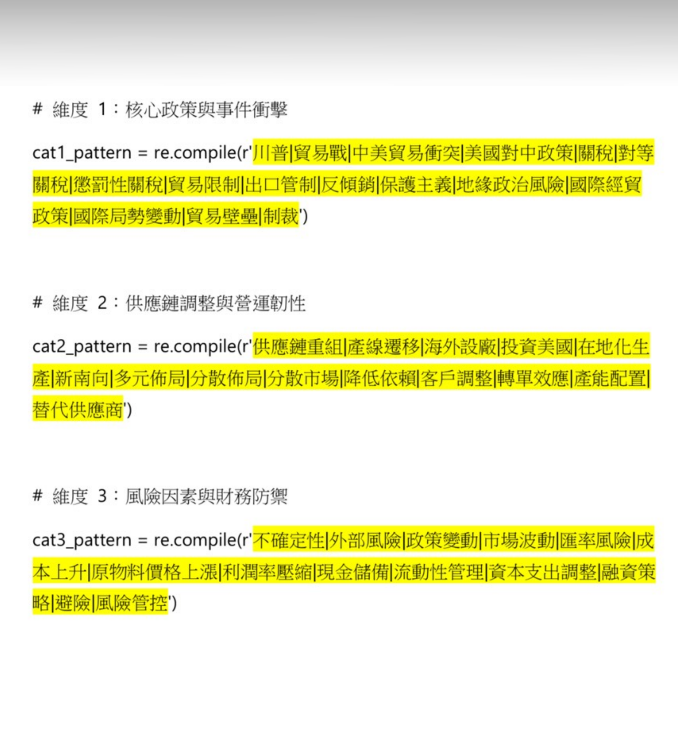


#### 維度 1

In [7]:
folder_path = r"C:\Users\user\Documents\實證研究\pdf_crawling\年報"
cat1_pattern=count_keywords_in_pdfs(df_fs_code, folder_path, year="2024", regex_pattern=r'川普|貿易戰|中美貿易衝突|美國對中政策|關稅|對等關稅|懲罰性關稅|貿易限制|出口管制|反傾銷|保護主義|地緣政治風險|國際經貿政策|國際局勢變動|貿易壁壘|制裁')


[進度] 正在處理代號: 1101
目前在處理第 1 / 1906 個檔案
這份文件共有 123 頁
  已處理 50 / 123 頁...
  已處理 100 / 123 頁...
  > 處理完成，關鍵字出現總次數: 4

[進度] 正在處理代號: 1102
目前在處理第 2 / 1906 個檔案
這份文件共有 363 頁
  已處理 50 / 363 頁...
  已處理 100 / 363 頁...
  已處理 150 / 363 頁...
  已處理 200 / 363 頁...
  已處理 250 / 363 頁...
  已處理 300 / 363 頁...
  已處理 350 / 363 頁...
  > 處理完成，關鍵字出現總次數: 2

[進度] 正在處理代號: 1103
目前在處理第 3 / 1906 個檔案
這份文件共有 113 頁
  已處理 50 / 113 頁...
  已處理 100 / 113 頁...
  > 處理完成，關鍵字出現總次數: 4

[進度] 正在處理代號: 1104
目前在處理第 4 / 1906 個檔案
這份文件共有 73 頁
  已處理 50 / 73 頁...
  > 處理完成，關鍵字出現總次數: 0

[進度] 正在處理代號: 1108
目前在處理第 5 / 1906 個檔案
這份文件共有 85 頁
  已處理 50 / 85 頁...
  > 處理完成，關鍵字出現總次數: 4

[進度] 正在處理代號: 1109
目前在處理第 6 / 1906 個檔案
這份文件共有 88 頁
  已處理 50 / 88 頁...
  > 處理完成，關鍵字出現總次數: 5

[進度] 正在處理代號: 1110
目前在處理第 7 / 1906 個檔案
這份文件共有 108 頁
  已處理 50 / 108 頁...
  已處理 100 / 108 頁...
  > 處理完成，關鍵字出現總次數: 0

[進度] 正在處理代號: 1201
目前在處理第 8 / 1906 個檔案
這份文件共有 110 頁
  已處理 50 / 110 頁...
  已處理 100 / 110 頁...
  > 處理完成，關鍵字出現總次數: 0

[進度] 正在處理代號: 1203
目前在處理第 9 / 1906 個檔案
這份文件共有 136 頁


In [8]:
cat2_pattern=count_keywords_in_pdfs(df_fs_code, folder_path, year="2024", regex_pattern=r'供應鏈重組|產線遷移|海外設廠|投資美國|在地化生產|新南向|多元佈局|分散佈局|分散市場|降低依賴|客戶調整|轉單效應|產能配置|替代供應商')
cat3_pattern=count_keywords_in_pdfs(df_fs_code, folder_path, year="2024", regex_pattern=r'不確定性|外部風險|政策變動|市場波動|匯率風險|成本上升|原物料價格上漲|利潤率壓縮|現金儲備|流動性管理|資本支出調整|融資策略|避險|風險管控')


[進度] 正在處理代號: 1101
目前在處理第 1 / 1906 個檔案
這份文件共有 123 頁
  已處理 50 / 123 頁...
  已處理 100 / 123 頁...
  > 處理完成，關鍵字出現總次數: 0

[進度] 正在處理代號: 1102
目前在處理第 2 / 1906 個檔案
這份文件共有 363 頁
  已處理 50 / 363 頁...
  已處理 100 / 363 頁...
  已處理 150 / 363 頁...
  已處理 200 / 363 頁...
  已處理 250 / 363 頁...
  已處理 300 / 363 頁...
  已處理 350 / 363 頁...
  > 處理完成，關鍵字出現總次數: 0

[進度] 正在處理代號: 1103
目前在處理第 3 / 1906 個檔案
這份文件共有 113 頁
  已處理 50 / 113 頁...
  已處理 100 / 113 頁...
  > 處理完成，關鍵字出現總次數: 2

[進度] 正在處理代號: 1104
目前在處理第 4 / 1906 個檔案
這份文件共有 73 頁
  已處理 50 / 73 頁...
  > 處理完成，關鍵字出現總次數: 0

[進度] 正在處理代號: 1108
目前在處理第 5 / 1906 個檔案
這份文件共有 85 頁
  已處理 50 / 85 頁...
  > 處理完成，關鍵字出現總次數: 0

[進度] 正在處理代號: 1109
目前在處理第 6 / 1906 個檔案
這份文件共有 88 頁
  已處理 50 / 88 頁...
  > 處理完成，關鍵字出現總次數: 0

[進度] 正在處理代號: 1110
目前在處理第 7 / 1906 個檔案
這份文件共有 108 頁
  已處理 50 / 108 頁...
  已處理 100 / 108 頁...
  > 處理完成，關鍵字出現總次數: 0

[進度] 正在處理代號: 1201
目前在處理第 8 / 1906 個檔案
這份文件共有 110 頁
  已處理 50 / 110 頁...
  已處理 100 / 110 頁...
  > 處理完成，關鍵字出現總次數: 0

[進度] 正在處理代號: 1203
目前在處理第 9 / 1906 個檔案
這份文件共有 136 頁


In [10]:
print("類別1 (EPU) 關鍵字計數:", np.mean(cat1_pattern))
print("類別2 (供應鏈) 關鍵字計數:", np.mean(cat2_pattern))
print("類別3 (風險管理) 關鍵字計數:", np.mean(cat3_pattern))

類別1 (EPU) 關鍵字計數: 3.5383001049317944
類別2 (供應鏈) 關鍵字計數: 0.5136411332633788
類別3 (風險管理) 關鍵字計數: 5.780692549842603


#### 將維度1+2+3 加入實證模型中

In [ ]:
df_fs["維度1_事件衝擊"]=cat1_pattern
df_fs["維度2_供應鏈"]=cat2_pattern
df_fs["維度3_風險管理"]=cat3_pattern
df_fs.to_csv(r"C:\Users\user\Documents\實證研究\python_ds\實證模型.csv", index=False,encoding="cp950") 

In [34]:
%pip install pymupdf
import fitz
print(fitz.__doc__)


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: C:\Users\user\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


  Using cached pymupdf-1.26.7-cp310-abi3-win_amd64.whl.metadata (3.4 kB)
Using cached pymupdf-1.26.7-cp310-abi3-win_amd64.whl (18.4 MB)
Note: you may need to restart the kernel to use updated packages.
PyMuPDF 1.26.7: Python bindings for the MuPDF 1.26.12 library (rebased implementation).
Python 3.11 running on win32 (64-bit).

